# Time Series Fundamentals: Decomposing the Signals

Before we use Machine Learning, we must understand that most time series are just a combination of three patterns:
1. **Trend**: The long-term direction (up/down).
2. **Seasonality**: Periodic fluctuations (daily, weekly, yearly).
3. **Residuals (Noise)**: Unpredictable random events.

In this notebook, we will manually "deconstruct" the Airline Passenger dataset using simple data analysis techniques.

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

url = "https://storage.googleapis.com/edulabs-public-datasets/airline-passengers.csv"
df = pd.read_csv(url)
df['Month'] = pd.to_datetime(df['Month'])
df = df.set_index('Month')
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


<Axes: xlabel='Month'>

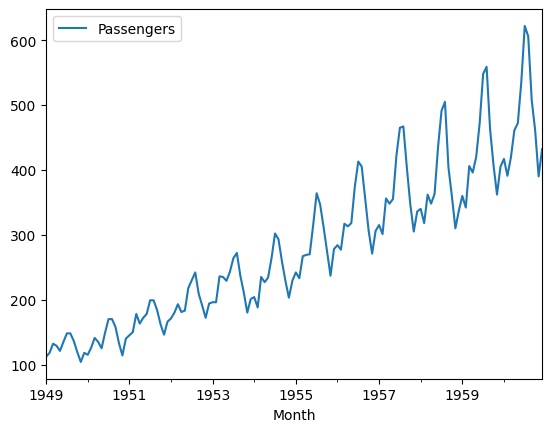

In [3]:
df.plot()

## 1. Capturing the Trend
To see the trend clearly, we can use a **Rolling Mean**. By averaging over a 12-month window, we "wash away" the seasonal peaks.

In [ ]:
# Calculate 12-month rolling average
df['Trend'] = df['Passengers'].rolling(window=12, center=True).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['Passengers'], name='Raw Data', line=dict(color='gray', width=1)))
fig.add_trace(go.Scatter(x=df.index, y=df['Trend'], name='12-Month Trend', line=dict(color='#FF4B4B', width=3)))

fig.update_layout(title='Extracting the Trend (Long-term Direction)')
fig.show()

## 2. Isolating Seasonality
If we subtract the **Trend** from the **Raw Data**, we are left with the fluctuations that happen every year. This is the **Seasonal** component.

In [5]:
# Remove the trend to see the cycles
df['Detrended'] = df['Passengers'] - df['Trend']

fig = px.line(df, x=df.index, y='Detrended', 
              title='Isolating Seasonality (The Yearly Cycle)',
              template='plotly_dark')
fig.update_traces(line_color='#00D4FF')
fig.show()

## 3. The Full Picture: Decomposition
Now let's look at all components together. This is exactly what Prophet does inside its mathematical model.

In [6]:
fig = make_subplots(rows=3, cols=1, 
                    subplot_titles=("Raw Data", "Trend (Long Term)", "Seasonality (Repeating Cycle)"),
                    vertical_spacing=0.1)

fig.add_trace(go.Scatter(x=df.index, y=df['Passengers'], name='Raw'), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['Trend'], name='Trend', line=dict(color='red')), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['Detrended'], name='Seasonality', line=dict(color='cyan')), row=3, col=1)

fig.update_layout(height=800, showlegend=False, template='plotly_dark', title='Time Series Decomposition Overview')
fig.show()

### Discussion for Participants:
- **Trend**: In a FAB environment, this could be the gradual degradation of a part.
- **Seasonality**: This could be shift-related performance or weekly cleaning cycles.
- **ML Goal**: We want to predict the *Trend* and the *Seasonality* to know where the sensor will be tomorrow!